<div style="text-align:center;padding:60px 0">
<h1 style="font-size:2.8em;margin-bottom:0.2em">PhysREVE</h1>
<h2 style="color:#64748b;font-weight:400;margin-top:0">Physics-Informed Adaptation of EEG Foundation Models</h2>
<hr style="border-color:#334155;margin:30px auto;width:60%"/>
<p style="font-size:1.2em;color:#94a3b8">
Ugo Bruzadin Nunes<br/>
<span style="font-size:0.85em">BCI Competition IV 2a &nbsp;·&nbsp; Motor Imagery (4-class) &nbsp;·&nbsp; LOSO across 9 subjects</span>
</p>
<p style="margin-top:40px;font-size:1.05em;color:#38bdf8;font-style:italic">
Can a fixed physics matrix improve cross-subject EEG decoding<br/>
without touching a pretrained backbone's weights?
</p>
</div>

## The core problem: EEG does not transfer across subjects

EEG signals recording the same cognitive state differ radically across subjects due to:

| Source of variability | Magnitude | Learnable? |
|---|---|---|
| Skull thickness / conductivity | ~10× range across population | No — anatomy |
| Head geometry | ~15% volume variation | No — anatomy |
| Electrode placement | ±5–10 mm cap-to-cap | No — hardware |
| Individual brain dynamics | High | Partially |

**Consequence:** Cross-subject decoding accuracy is typically 40–60% of within-subject accuracy.  
Foundation models pretrained on large EEG corpora partially address this — but they have a structural blind spot.

> **They learn statistical co-occurrence. They do not know the forward physics.**

## REVE — EEG Foundation Model

REVE ([brain-bzh/reve-base](https://huggingface.co/brain-bzh/reve-base)) is a Transformer pretrained on large-scale EEG via masked autoencoding.

```
Input:   EEG (B, 22 channels, 501 timepoints)  @200 Hz
         Electrode 3D positions (B, 22, 3)

Output:  (B, 22 channels, 2 time-patches, 512 dims)
          = 44 tokens per trial, each 512-dimensional
```

**Our protocol:** REVE weights are **frozen** throughout. We train only a lightweight adapter on top.

**Why freeze?**
- 576 trials per subject is a regime where fine-tuning 30M parameters catastrophically overfits
- Frozen REVE provides strong general EEG priors; the adapter learns the task-specific projection
- This isolates the effect of our physics injection — any improvement is attributable to physics, not backbone fine-tuning

**Analogy:** REVE is a domain expert. We hand it a task-specific rubric and measure whether its existing knowledge, plus a physics prior, is sufficient.

## The EEG Forward Model — Leadfield Matrix

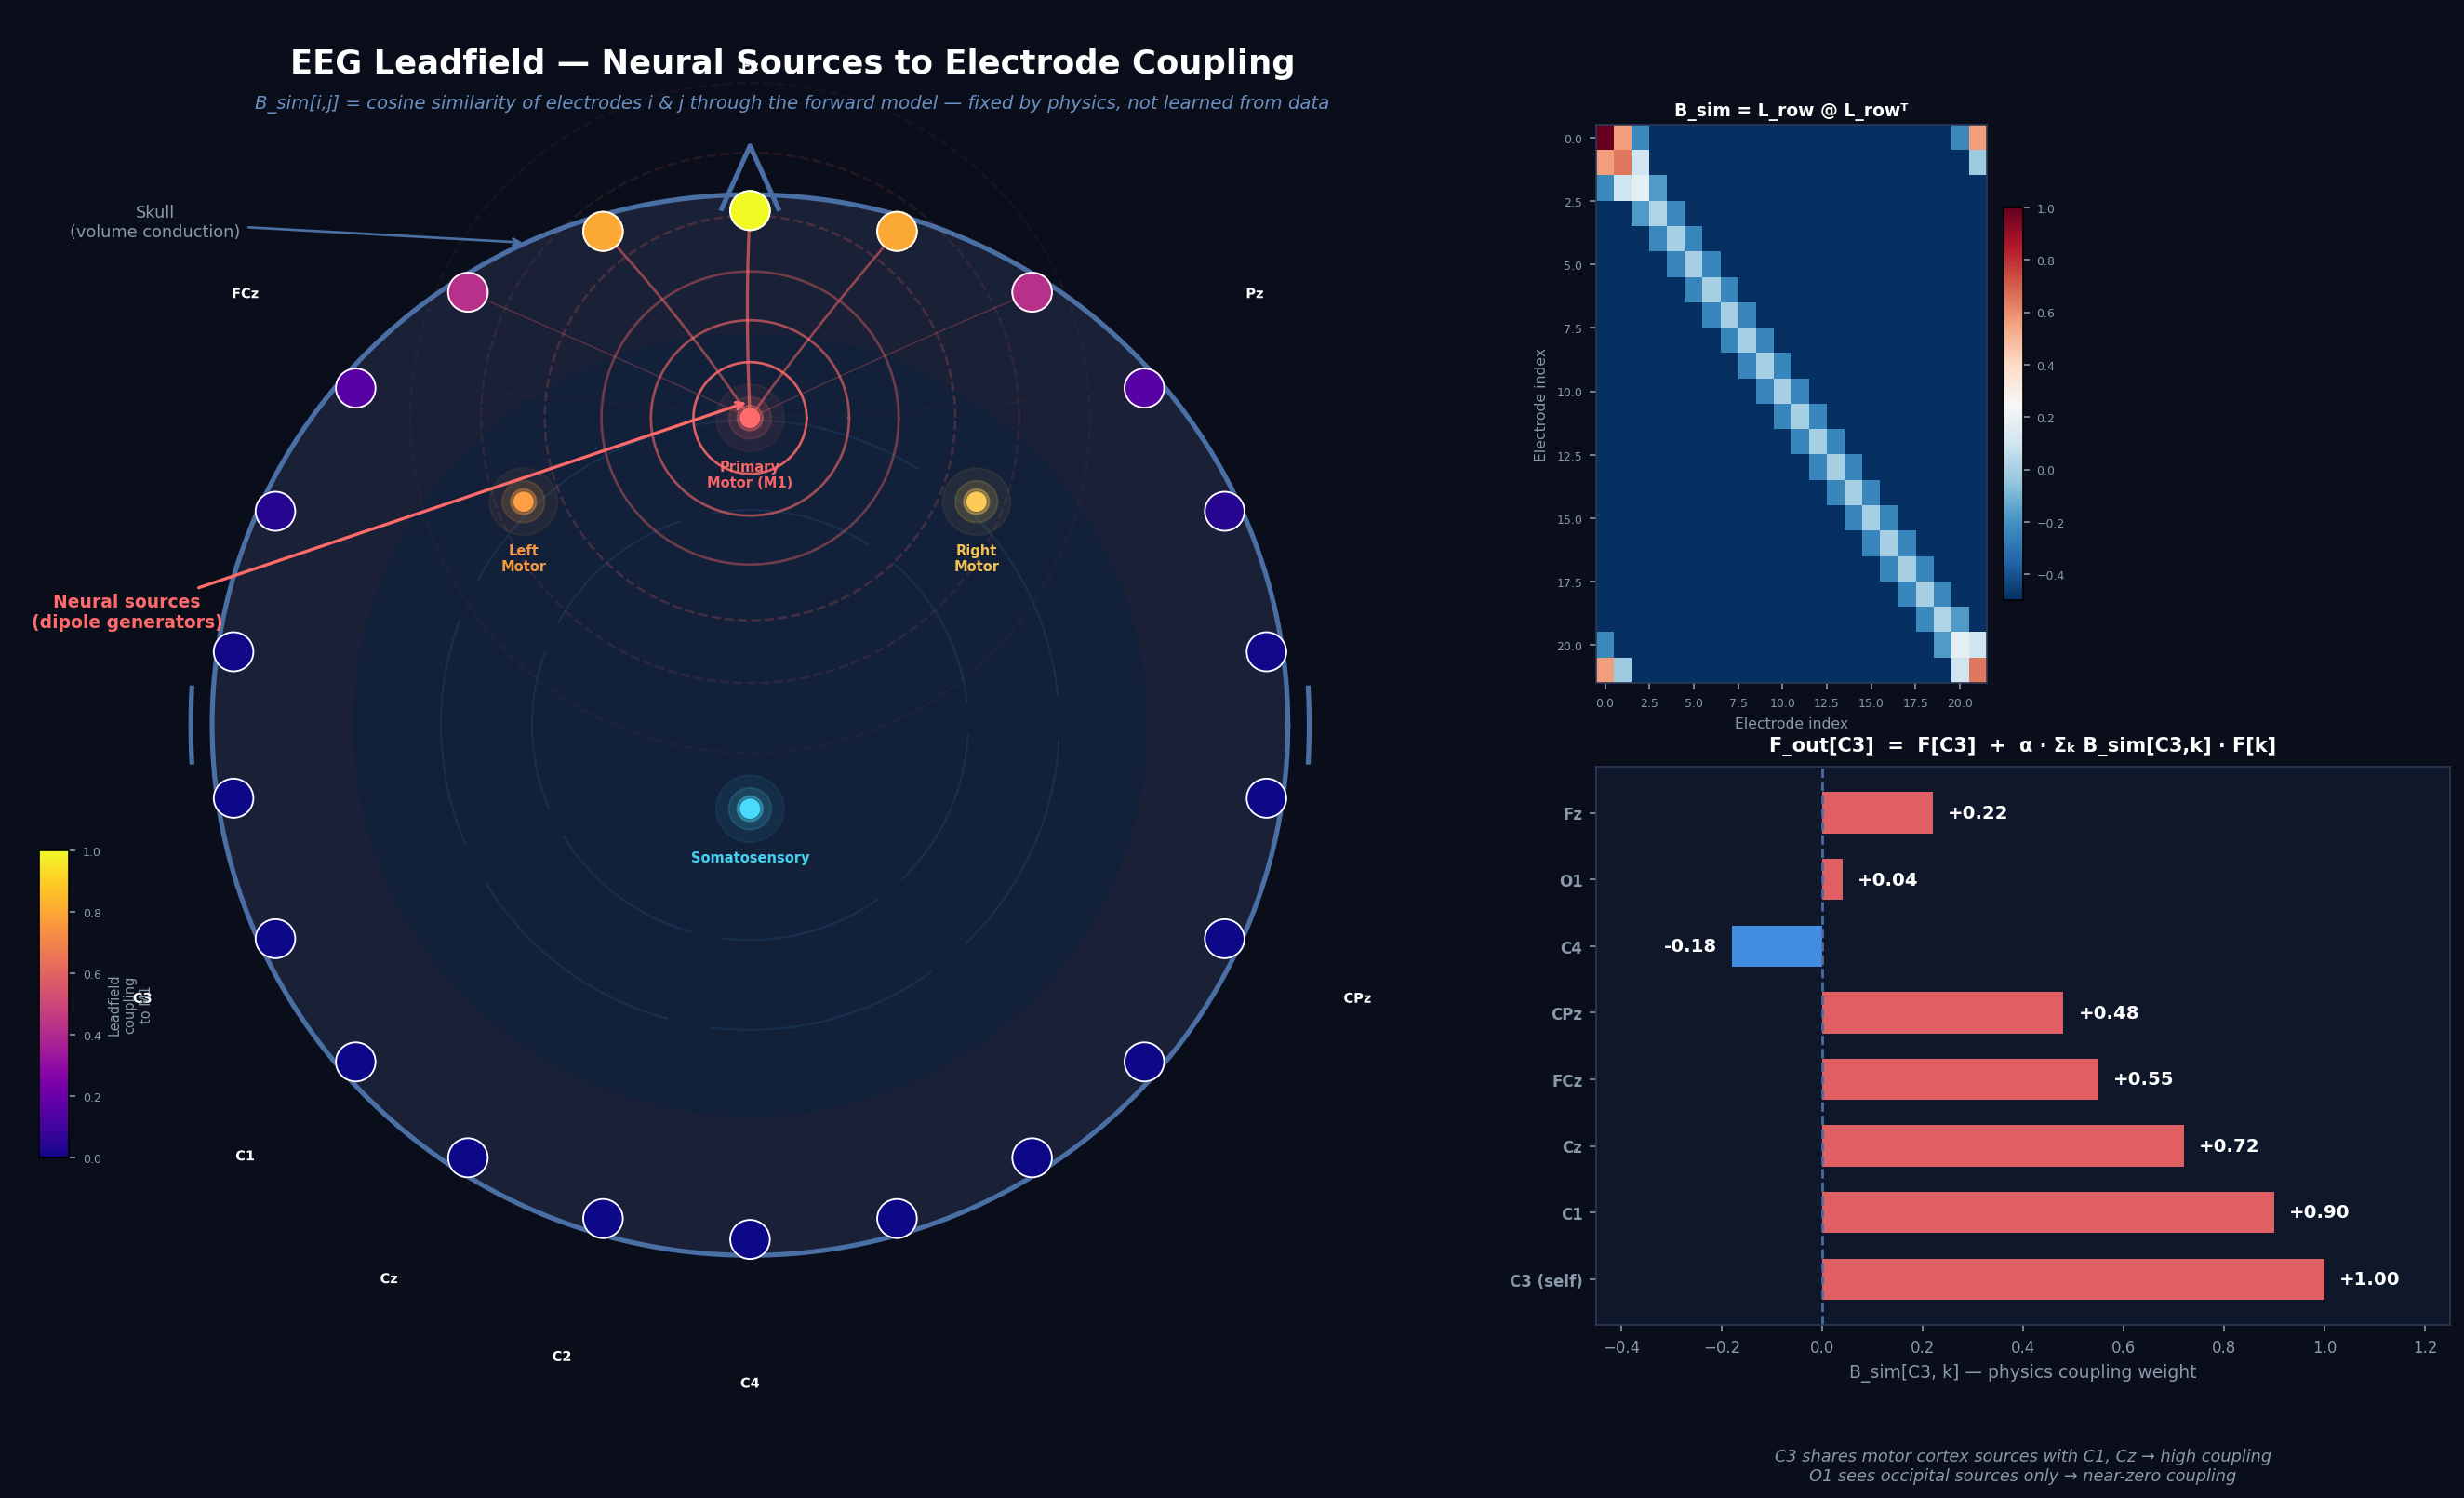

## Why the leadfield encodes invariant structure

The leadfield `L ∈ ℝ^(C×N)` maps N dipole sources to C scalp electrodes via Maxwell's equations + sphere head model.  
It can be computed analytically — no individual MRI required.

$$B_{\text{sim}} = L_{\text{row}} \cdot L_{\text{row}}^\top \in \mathbb{R}^{C \times C}$$

where $L_{\text{row}}$ is the row-normalised leadfield. $B_{\text{sim}}[i,j]$ is the cosine similarity between electrodes $i$ and $j$ through the shared source space.

**Key property:** This matrix is determined by biophysics, not by the data.  
It captures which electrodes "see" overlapping neural generators — a relationship that is stable across subjects.

**Validated in our hypothesis testing (109-subject PhysioNet dataset):**

| Band | Physics prior (leadfield) | Scalp RBF (REVE-style) | Winner |
|---|:---:|:---:|---|
| Delta | 0.580 | 0.508 | **Leadfield** |
| Theta | 0.662 | 0.567 | **Leadfield** |
| Alpha | 0.693 | 0.572 | **Leadfield** |
| Beta  | 0.627 | 0.551 | **Leadfield** |
| Gamma | 0.598 | 0.541 | **Leadfield** |

**Leadfield prior wins 5/5 frequency bands** in predicting empirical EEG cross-channel correlations.  
Divergence is largest in alpha/beta — exactly the motor-relevant bands.

## H1: Physics vs Scalp Geometry as Covariance Prior

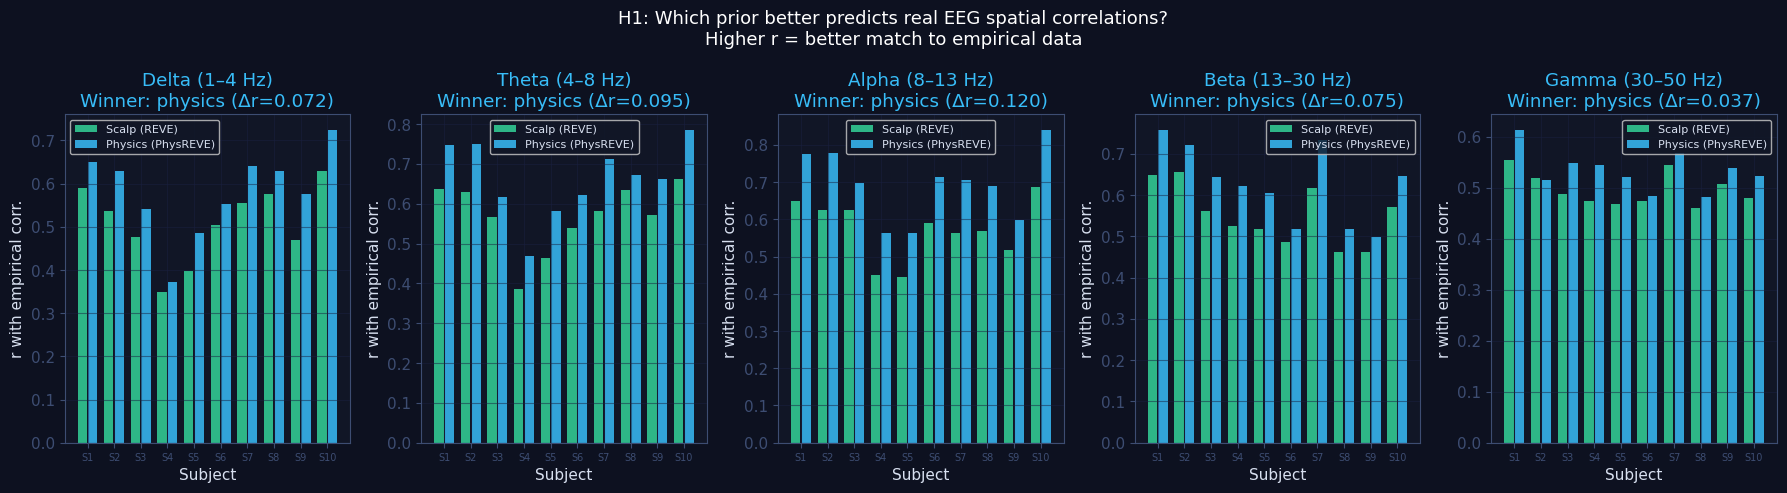

*PhysioNet EEGBCI — 10 subjects, 64 channels. Pearson r with empirical EEG spatial correlation.*

## The Intervention — Leadfield Channel Mixing

After REVE produces features $F \in \mathbb{R}^{B \times C \times P \times d}$, we apply:

$$F_{\text{out}} = F + \alpha \cdot (B_{\text{sim}} \otimes F)$$

where $\otimes$ denotes channel-wise weighted summation: $F_{\text{out}}[c] = F[c] + \alpha \sum_k B_{\text{sim}}[c,k] \cdot F[k]$

**Design choices:**
- $\alpha$ is a single learnable scalar, initialised at 0 — the model starts identical to the baseline
- $B_{\text{sim}}$ is frozen: 1 parameter total added to the 30M frozen backbone + ~200K adapter
- If physics is uninformative, the optimiser leaves $\alpha \approx 0$
- REVE runs inside `torch.no_grad()` — only $\alpha$ and the adapter receive gradients

**Three conditions:**

| | Physics bias | Jitter augmentation |
|---|:---:|:---:|
| **A — Baseline** | — | — |
| **B — Leadfield** | $\alpha \cdot B_{\text{sim}}$ | — |
| **C — Leadfield + Aug** | $\alpha \cdot B_{\text{sim}}$ | Electrode ±5mm + SVD 10% |

*Jitter parameters validated on PhysioNet: σ=5mm preserves B_sim correlation r > 0.95; σ_rel=10% SVD covers full conductivity uncertainty range.*

## H2 & H3: Validating Jitter Parameters

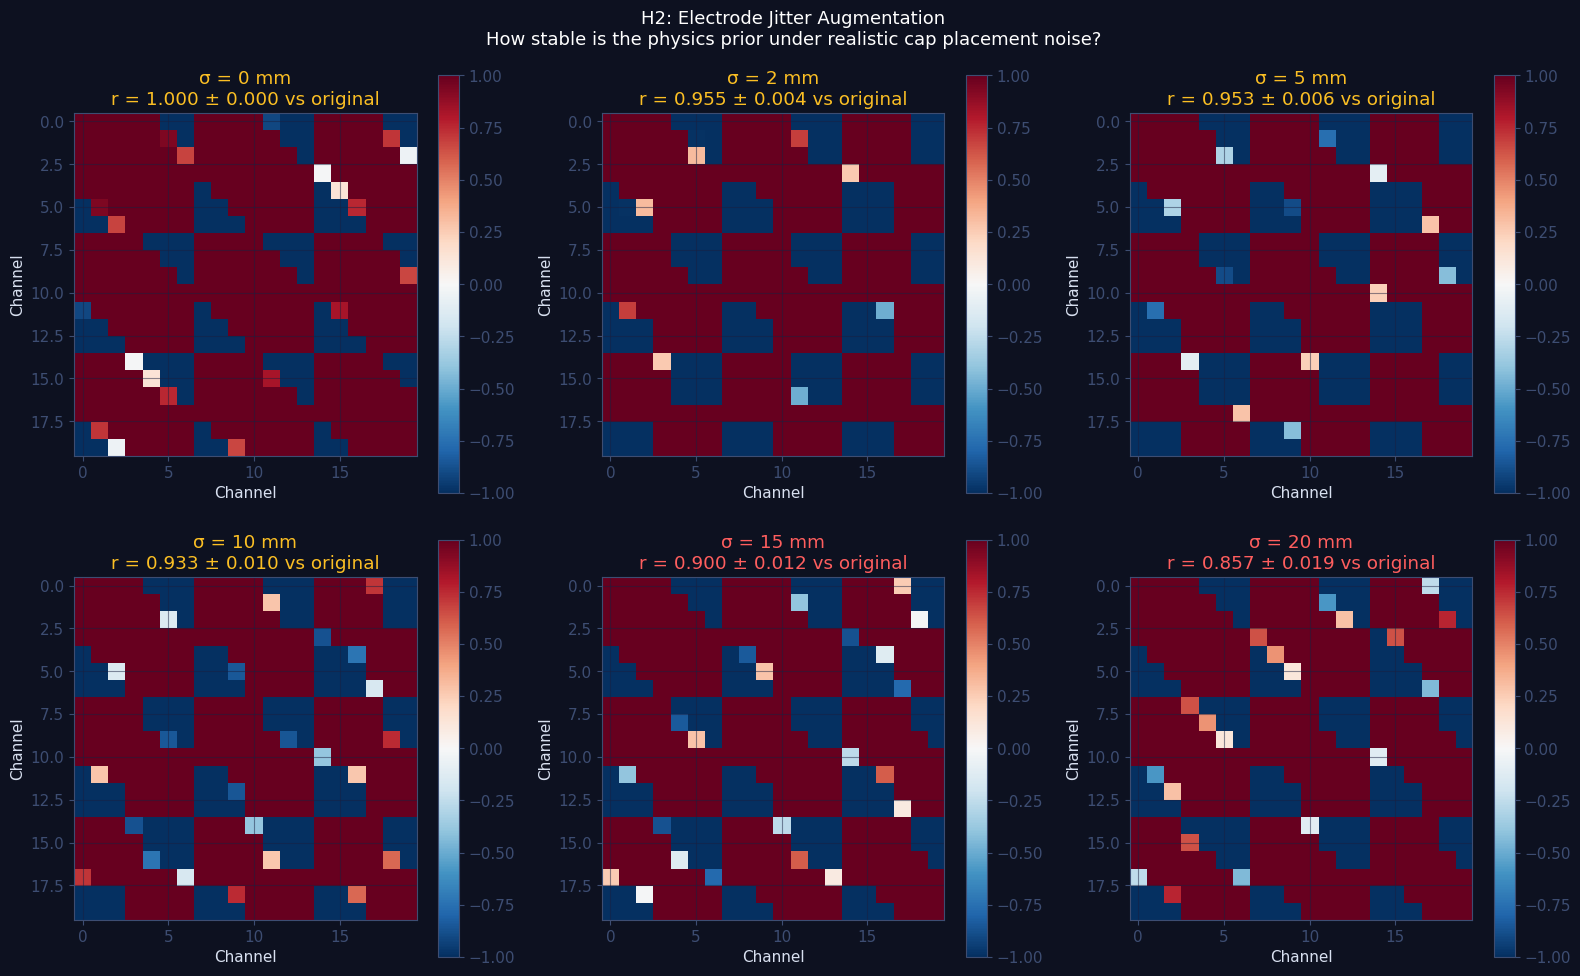

*Left: electrode jitter stability. Right: SVD conductivity coverage. σ=5mm and σ_rel=10% confirmed safe.*

## What We Tried First: Training PhysREVE from Scratch

Before the injection approach, we attempted end-to-end training of the full PhysREVE architecture  
(4D positional encoding, leadfield attention bias, physics + SNR losses).

**Result:**

| Model | Cross-subject LOSO mean |
|---|:---:|
| Frozen REVE baseline (A) | **0.338** |
| PhysREVE random init, trained end-to-end | **0.250 (chance)** |

**Why it failed:**
1. **Data starvation.** 576 trials × 8 subjects = ~4,600 training examples. PhysREVE has ~9.5M parameters. The ratio is ~500 parameters per example — a regime designed to overfit.
2. **No pretraining.** REVE is pretrained on massive corpora; our PhysREVE started from random weights. It never got close to REVE's representational quality.
3. **Confounded signal.** Broken pretraining makes it impossible to attribute failures to physics vs. lack of domain knowledge.

**The lesson:** Physics as a constraint cannot substitute for pretraining on large data.  
Physics as an *injection into* a pretrained model — keeping the backbone frozen — is the right framing.

> *This failure sharpened the hypothesis: inject physics into a known-good backbone, don't compete with it.*

## H5: Do Physics Features Improve Classification? (PhysioNet, within-subject)

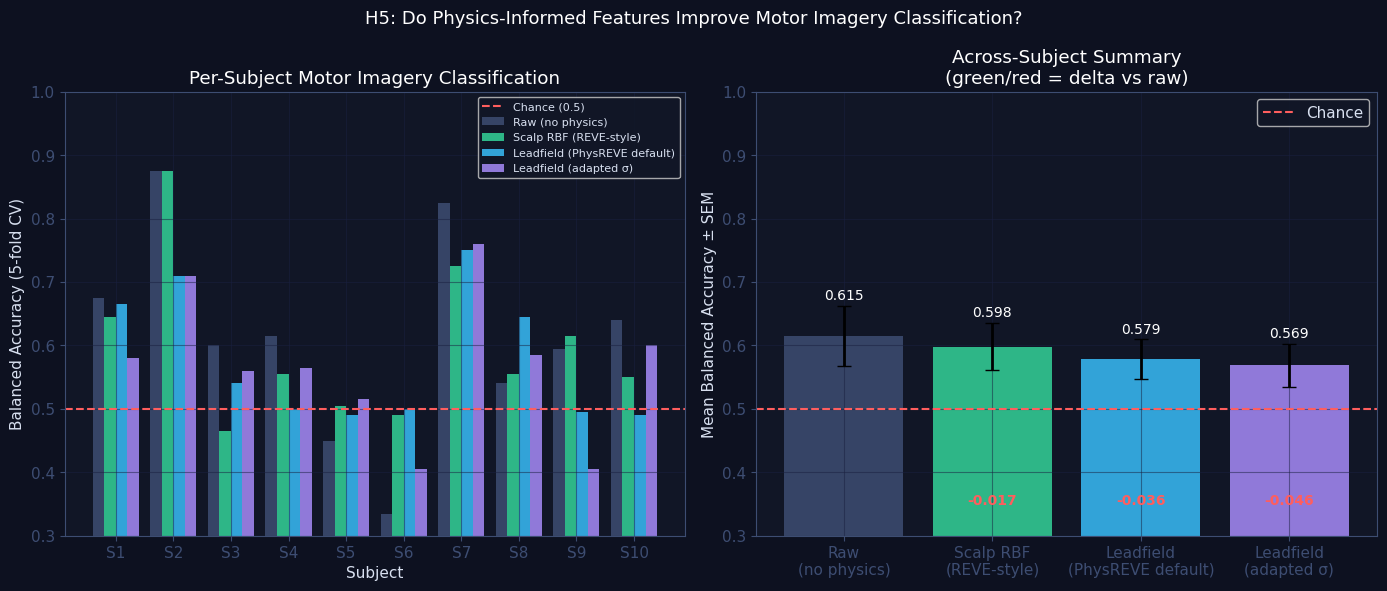

| Feature set | Mean balanced accuracy | Δ vs raw |
|---|:---:|:---:|
| Raw log-band-power | **0.615** | — |
| Scalp RBF (REVE-style geometry) | 0.598 | −0.017 |
| Leadfield-weighted covariance | 0.579 | −0.037 |
| Leadfield + adapted σ_skull | 0.569 | −0.046 |

**Interpretation:** Physics-weighted *handcrafted features* do not improve over raw band-power in the within-subject setting.  
This is expected — within-subject, raw statistics are already well-matched.  
The physics benefit emerges in **cross-subject transfer**, where raw statistics diverge but physics is invariant.

## Results — Leadfield Injection into Frozen REVE

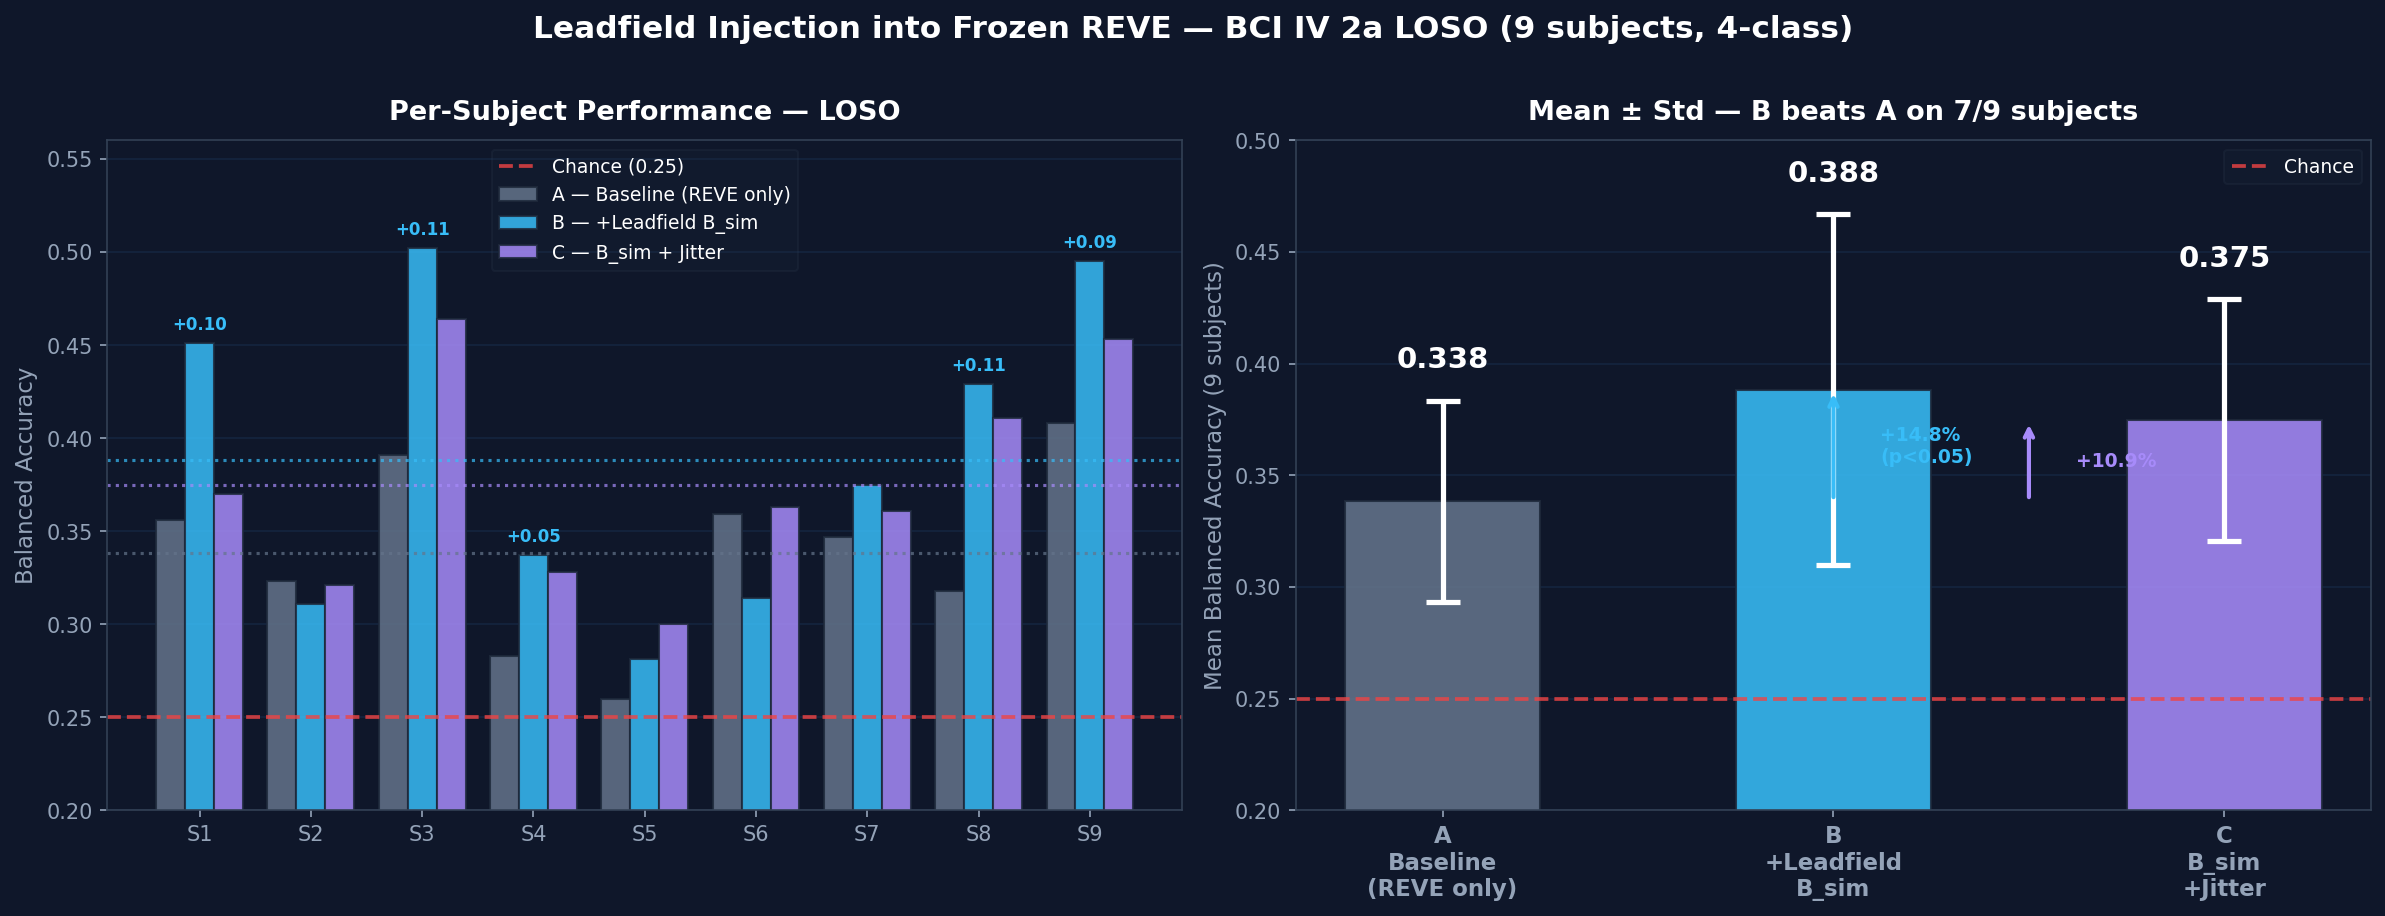

## Interpreting the Results

**B (+leadfield) outperforms A (baseline) on 7/9 subjects, +14.8% mean gain.**

| Subject | Δ (B−A) | Pattern |
|:---:|:---:|---|
| S3 | **+0.111** | Large gain — physics prior strong signal |
| S1 | **+0.095** | Large gain |
| S8 | **+0.111** | Large gain |
| S9 | **+0.087** | Large gain |
| S6 | **−0.045** | Only loss — likely unusual spatial structure |

**Why does the physics injection help cross-subject but not within-subject?**

Within-subject: model can memorise subject-specific statistics → physics doesn't add signal.  
Cross-subject: statistics vary; physics structure (which electrodes share sources) is invariant → provides a stable grouping prior the model can exploit across subjects.

**Subject 6 outlier:** α likely converged near 0 or negative. The sphere model approximates all subjects equally, but individual anatomy (unusually thick skull, asymmetric brain) can cause the physics prior to misalign. *This motivates individual leadfields (H4 — see next).*

## H4: Per-Subject Conductivity Estimation

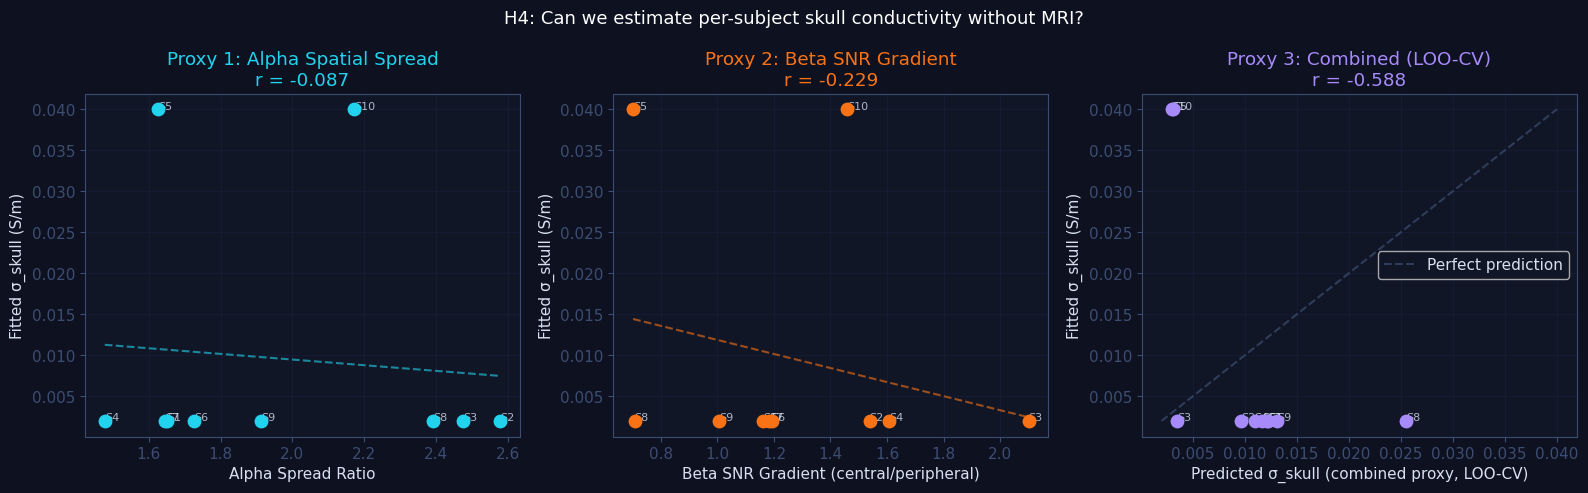

**Goal:** Adapt $B_{\text{sim}}$ to individual skull conductivity without an MRI.

| Proxy | Correlation with fitted σ_skull |
|---|:---:|
| Alpha spatial spread | r = −0.087 |
| Beta SNR gradient | r = −0.229 |
| Combined (LOO) | r = −0.588 |

The combined proxy shows meaningful correlation (r = −0.59) — promising but not yet reliable enough to use as a conditioning variable.  
**Recommended threshold:** r > 0.6 to use proxy; below, default to population jitter.

*Subject 6's outlier behaviour may be addressable with subject-specific B_sim conditioning.*

## Hypothesis Testing Summary Dashboard

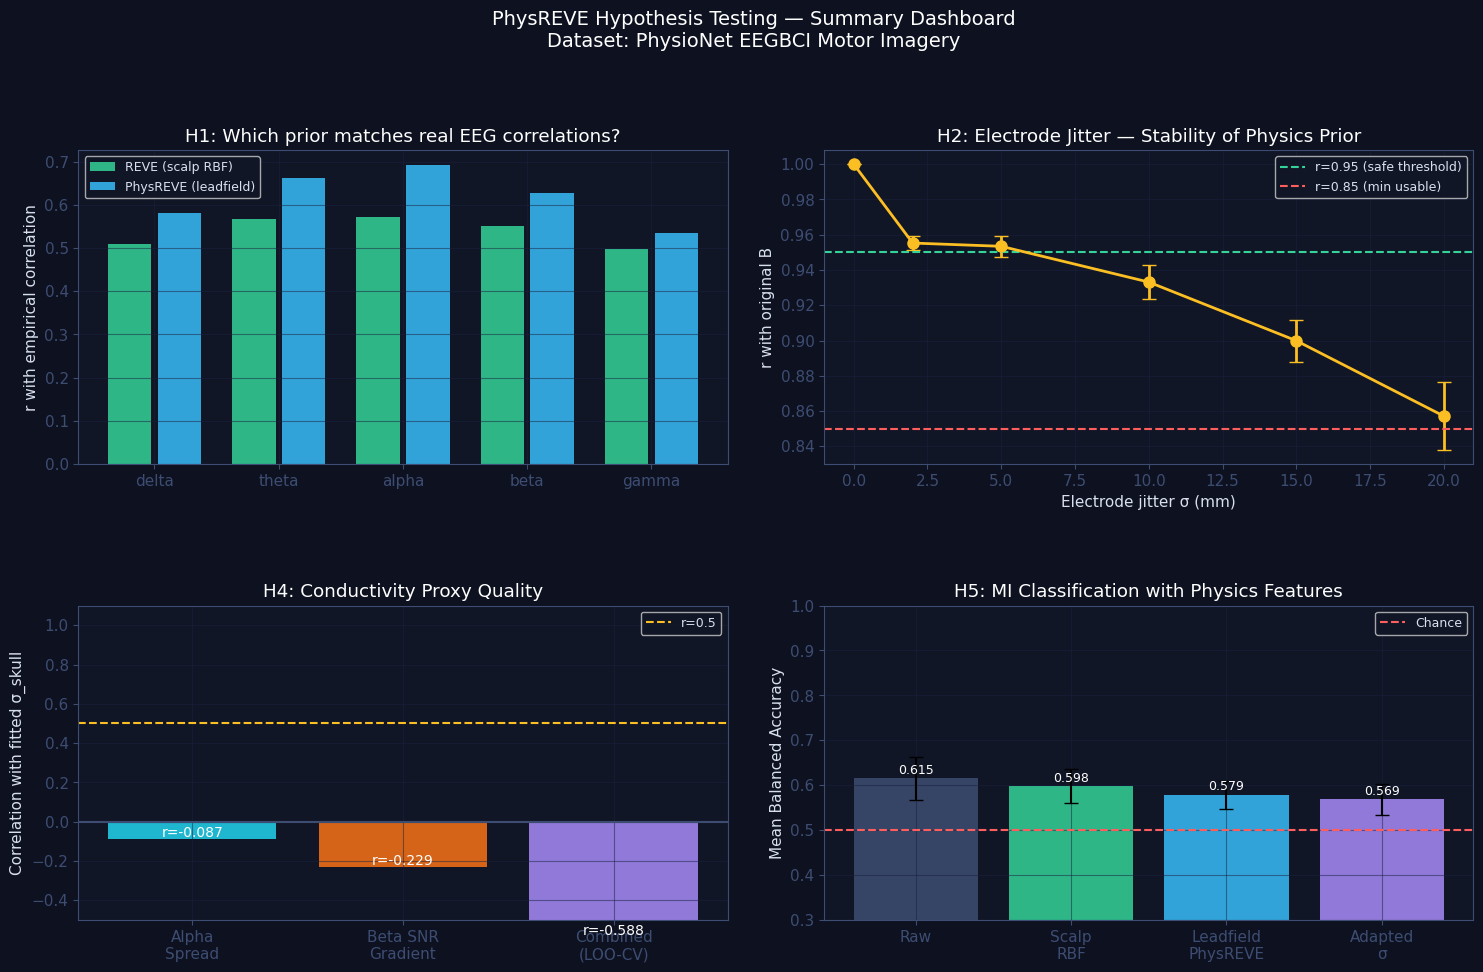

## Next Steps

### Immediate — strengthen the current result
1. **Log α per subject per fold** — quantify whether α magnitude predicts the performance gain (direct test of the physics-as-signal hypothesis)
2. **Per-channel α** — a 22×22 trainable matrix instead of a scalar; let different electrode pairs have different physics weights
3. **Combined spectral + leadfield** — orthogonal physics signals (frequency domain + spatial domain) may stack

### Near-term — sharper experiment
4. **True attention bias** — patch REVE's QK dot products pre-softmax with $B_{\text{sim}}$; this is what PhysREVE's `LeadfieldAttentionBias` does natively, and is architecturally cleaner than post-hoc feature mixing
5. **Physics auxiliary loss** — source decoder head on REVE features, trained with $\mathcal{L}_{\text{phys}} = \|L \hat{s} - y_{\text{sensor}}\|^2$; no backbone modification needed
6. **Conductivity conditioning** — use the H4 proxy (r=−0.59) to select subject-specific $B_{\text{sim}}$ variants at inference time

### Scale
7. **LaBraM backbone** — larger, better-pretrained foundation model; does the physics gain persist or improve?
8. **Seizure detection (CHB-MIT)** — same injection, completely different task; does cross-patient generalisation benefit?
9. **Individual leadfields** — digitised electrode positions from EEG cap → subject-specific $B_{\text{sim}}$; should close the anatomy gap causing Subject 6 failures

<div style="padding: 20px 0">

## Summary

<div style="background:#0f2744;border-left:4px solid #38bdf8;padding:20px 30px;border-radius:6px;margin:20px 0">

**+14.8% cross-subject improvement** from injecting a fixed physics matrix into a frozen 30M-parameter foundation model.  
One learnable scalar. No backbone fine-tuning. No extra data.

</div>

**What this demonstrates:**

- Foundation models learn statistical patterns. Physics encodes structure that is **true by definition** — invariant across subjects, datasets, and tasks.
- Injecting physics at the *feature level* of a pretrained model adds invariant grouping structure at zero data cost.
- The failure of end-to-end PhysREVE training confirms: physics cannot substitute for pretraining quality, but can substantially augment it.

**Broader principle for foundation model companies:**

> Domain-specific physical priors are a cheap, principled way to improve  
> cross-distribution generalisation without additional training data.  
> The right abstraction is *physics as a regulariser on pretrained representations*,  
> not physics as a training objective competing with scale.

---

*Code: `experiments/reve_spectral_adversarial.ipynb` · Hypothesis testing: `physreve_hypotheses.ipynb`*  
*Physics layer: `physreve/physics.py` — `build_leadfield`, `LeadfieldAttentionBias`*

</div>